In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [18]:
df = pd.read_excel("/content/drive/MyDrive/coo.xlsx")
m
print(df.head())

print(df.columns)


  trip       Time  Velocity       Distance  Initial SoC   Used SOC  \
0   A1  16.820000      26.49   7424.650000          86.9       5.4   
1   A2  23.550000      59.90  23493.627778          80.3      13.0   
2   A3  11.180000      68.70  12820.713889          83.5       8.4   
3   A4   6.870000      93.51  10728.183333          75.1       8.4   
4   A5  22.776667      32.60  12391.355556          66.7       6.5   

    Temperature   Weather  Unnamed: 8  Unnamed: 9  ...  Unnamed: 16  \
0          30.76        1         NaN         NaN  ...            1   
1          31.20        1         NaN         NaN  ...            1   
2          23.33        1         NaN         NaN  ...            1   
3          24.20        1         NaN         NaN  ...            1   
4          24.50        1         NaN         NaN  ...            1   

   Unnamed: 17  Unnamed: 18  Unnamed: 19  Unnamed: 20  Unnamed: 21  \
0          NaN          NaN    33.640000        26.49  14849.30000   
1          N

In [19]:
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())


trip              0
Time              0
Velocity          0
Distance          0
Initial SoC       0
Used SOC          0
 Temperature      0
Weather           0
Unnamed: 8       77
Unnamed: 9       77
Unnamed: 10       0
Unnamed: 11       0
Unnamed: 12       0
Unnamed: 13       0
Unnamed: 14       0
Unnamed: 15       0
Unnamed: 16       0
Unnamed: 17      77
Unnamed: 18      77
Unnamed: 19       0
Unnamed: 20       0
Unnamed: 21       0
Unnamed: 22       0
Unnamed: 23       0
Unnamed: 24       0
Unnamed: 25       0
dtype: int64

Total missing values: 308


In [20]:
df = df = df.fillna(df.mean(numeric_only=True))

In [22]:
df.columns

Index(['trip', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', 'Used SOC',
       ' Temperature ', 'Weather', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')

In [23]:
df = df[['trip', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', 'Used SOC',
       ' Temperature ', 'Weather']]

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   trip           77 non-null     object 
 1   Time           77 non-null     float64
 2   Velocity       77 non-null     float64
 3   Distance       77 non-null     float64
 4   Initial SoC    77 non-null     float64
 5   Used SOC       77 non-null     float64
 6    Temperature   77 non-null     float64
 7   Weather        77 non-null     int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 4.9+ KB


In [29]:
feature_cols = ['Weather', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', ' Temperature ']
target_col = 'Used SOC'

X = df[feature_cols]
y = df[target_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (77, 6)
Target shape: (77,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (61, 6)
Testing set size: (16, 6)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training features shape:", X_train_scaled.shape)



Scaled training features shape: (61, 6)


In [32]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model training completed.")


Model training completed.


In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("🔹 R² Score: ", round(r2, 4))
print("🔹 MAE:      ", round(mae, 4))
print("🔹 RMSE:     ", round(rmse, 4))


🔹 R² Score:  0.0545
🔹 MAE:       6.0673
🔹 RMSE:      18.6316


In [35]:
feature_importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance:\n", importance_df)


Feature Importance:
          Feature  Importance
3       Distance    0.891021
5   Temperature     0.058492
4   Initial SoC     0.023827
1           Time    0.014764
2      Velocity     0.008346
0        Weather    0.003550


In [38]:
import seaborn as sns
sns.set_style(style='whitegrid')

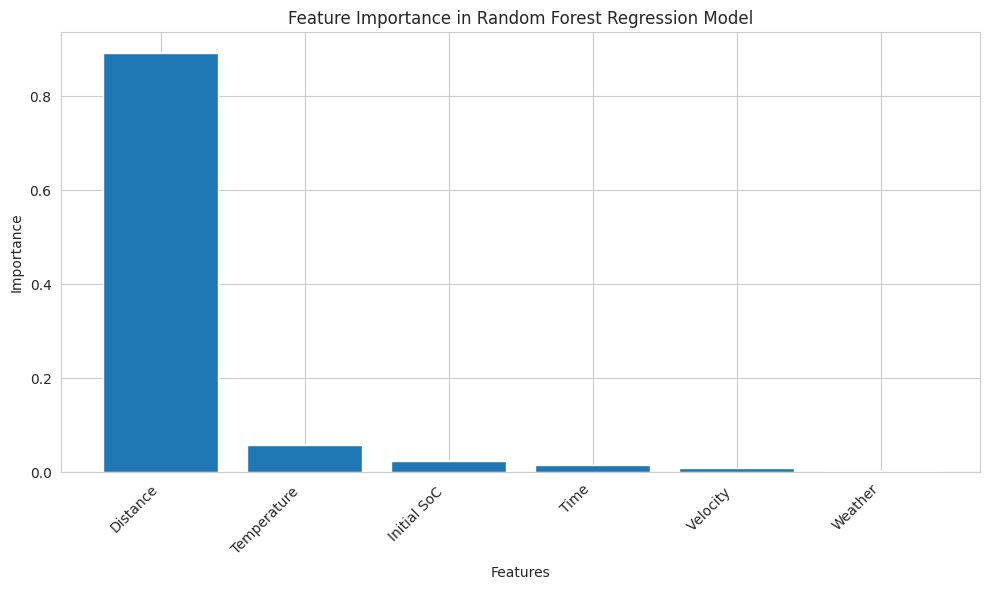

In [39]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Regression Model")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_excel("/content/drive/MyDrive/coo.xlsx")

feature_cols = ['Weather', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', ' Temperature ']
target_col = 'Used SOC'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression Performance:")
print(f"R² Score: {round(r2, 4)}")
print(f"MAE: {round(mae, 4)}")
print(f"RMSE: {round(rmse, 4)}")


Linear Regression Performance:
R² Score: 0.0917
MAE: 6.2455
RMSE: 18.2617


In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_excel("/content/drive/MyDrive/coo.xlsx")

feature_cols = ['Weather', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', ' Temperature ']
target_col = 'Used SOC'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("🔹 Random Forest Performance:")
print(f"R² Score: {round(r2, 4)}")
print(f"MAE: {round(mae, 4)}")
print(f"RMSE: {round(rmse, 4)}")

feature_importances = model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance (Random Forest):")
print(importance_df)


🔹 Random Forest Performance:
R² Score: 0.0545
MAE: 6.0673
RMSE: 18.6316

Feature Importance (Random Forest):
         Feature  Importance
3       Distance    0.891021
5   Temperature     0.058492
4   Initial SoC     0.023827
1           Time    0.014764
2      Velocity     0.008346
0        Weather    0.003550


In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_excel("/content/drive/MyDrive/coo.xlsx")
feature_cols = ['Weather', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', ' Temperature ']
target_col = 'Used SOC'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("🔹 Decision Tree Performance:")
print(f"R² Score: {round(r2, 4)}")
print(f"MAE: {round(mae, 4)}")
print(f"RMSE: {round(rmse, 4)}")


🔹 Decision Tree Performance:
R² Score: 0.0377
MAE: 6.5687
RMSE: 18.7959


In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_excel("/content/drive/MyDrive/coo.xlsx")
feature_cols = ['Weather', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', ' Temperature ']
target_col = 'Used SOC'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("🔹 Gradient Boosting Performance:")
print(f"R² Score: {round(r2, 4)}")
print(f"MAE: {round(mae, 4)}")
print(f"RMSE: {round(rmse, 4)}")


🔹 Gradient Boosting Performance:
R² Score: 0.0224
MAE: 6.0027
RMSE: 18.9453


In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_excel("/content/drive/MyDrive/coo.xlsx")
feature_cols = ['Weather', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', ' Temperature ']
target_col = 'Used SOC'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("🔹 XGBoost Performance:")
print(f"R² Score: {round(r2, 4)}")
print(f"MAE: {round(mae, 4)}")
print(f"RMSE: {round(rmse, 4)}")


🔹 XGBoost Performance:
R² Score: 0.0485
MAE: 6.2137
RMSE: 18.6904


In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_excel("/content/drive/MyDrive/coo.xlsx")
feature_cols = ['Weather', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', ' Temperature ']
target_col = 'Used SOC'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVR()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("🔹 SVR Performance:")
print(f"R² Score: {round(r2, 4)}")
print(f"MAE: {round(mae, 4)}")
print(f"RMSE: {round(rmse, 4)}")


🔹 SVR Performance:
R² Score: 0.0128
MAE: 6.6999
RMSE: 19.038


In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_excel("/content/drive/MyDrive/coo.xlsx")
feature_cols = ['Weather', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', ' Temperature ']
target_col = 'Used SOC'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("🔹 MLP Regressor Performance:")
print(f"R² Score: {round(r2, 4)}")
print(f"MAE: {round(mae, 4)}")
print(f"RMSE: {round(rmse, 4)}")


🔹 MLP Regressor Performance:
R² Score: 0.0549
MAE: 6.3902
RMSE: 18.6276


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


               Model        R²       MAE       RMSE
0  Linear Regression  0.091652  6.245474  18.261736
1      Random Forest  0.054484  6.067350  18.631614
2      Decision Tree  0.037740  6.568750  18.795861
3  Gradient Boosting  0.022382  6.002678  18.945263
4            XGBoost  0.048504  6.213654  18.690443
5                SVR  0.012783  6.699890  19.038041
6     MLP Regression  0.054887  6.390158  18.627646


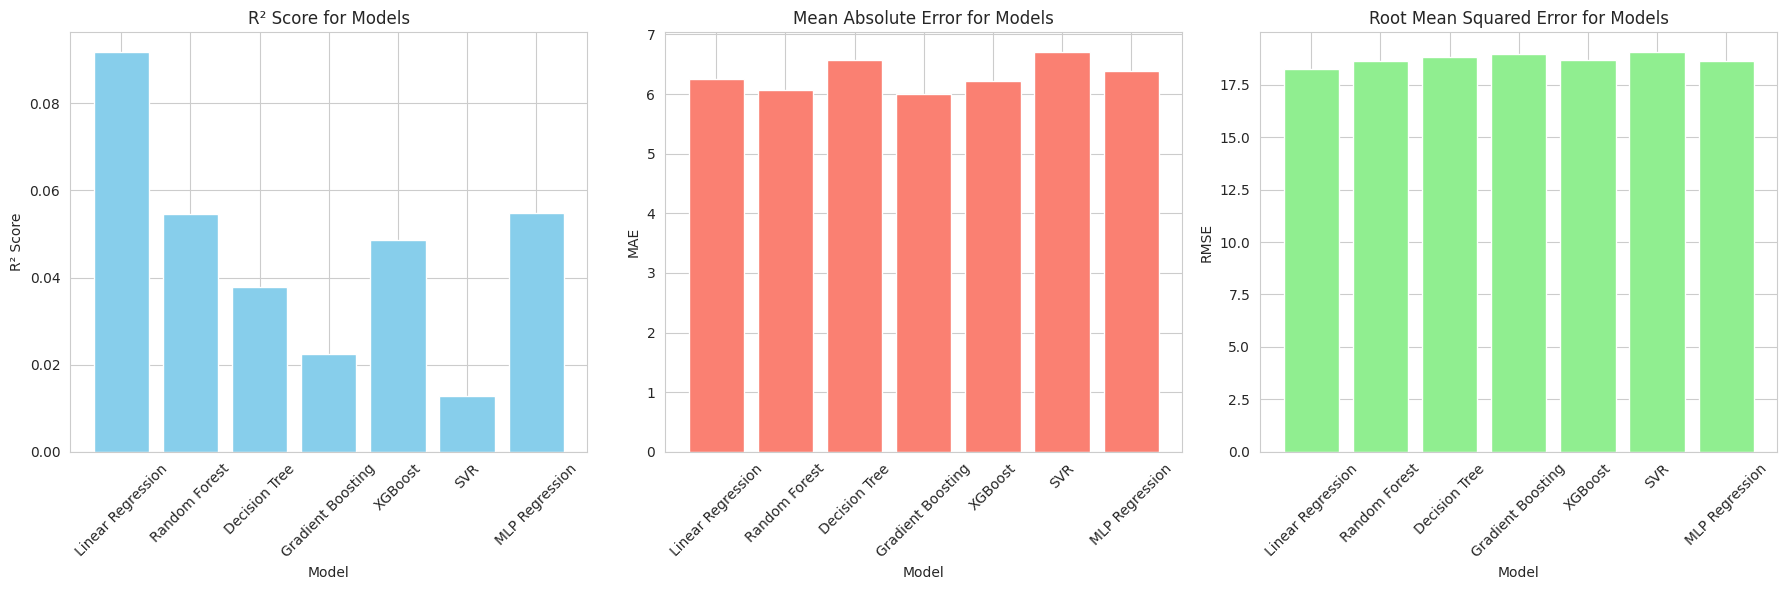

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_excel("/content/drive/MyDrive/coo.xlsx")

feature_cols = ['Weather', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', ' Temperature ']
target_col = 'Used SOC'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    "SVR": SVR(),
    "MLP Regression": MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
}

metrics = {
    "Model": [],
    "R²": [],
    "MAE": [],
    "RMSE": []
}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    metrics["Model"].append(model_name)
    metrics["R²"].append(r2)
    metrics["MAE"].append(mae)
    metrics["RMSE"].append(rmse)

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].bar(metrics_df["Model"], metrics_df["R²"], color='skyblue')
axes[0].set_title('R² Score for Models')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(metrics_df["Model"], metrics_df["MAE"], color='salmon')
axes[1].set_title('Mean Absolute Error for Models')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)
axes[2].bar(metrics_df["Model"], metrics_df["RMSE"], color='lightgreen')
axes[2].set_title('Root Mean Squared Error for Models')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('RMSE')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


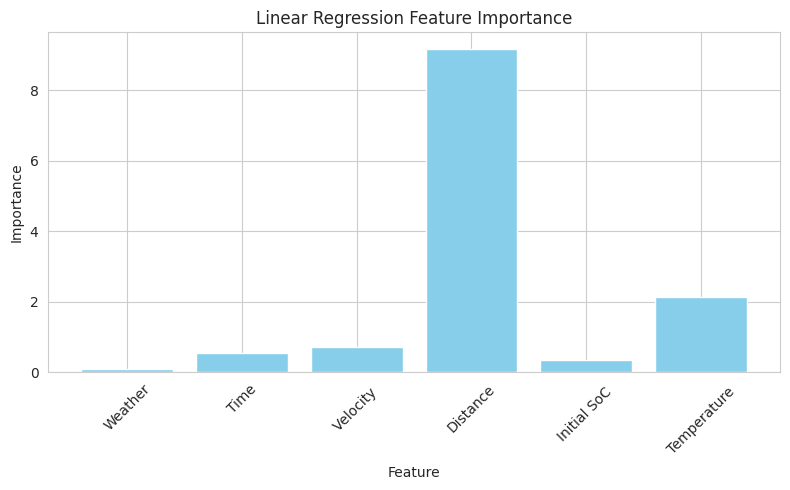

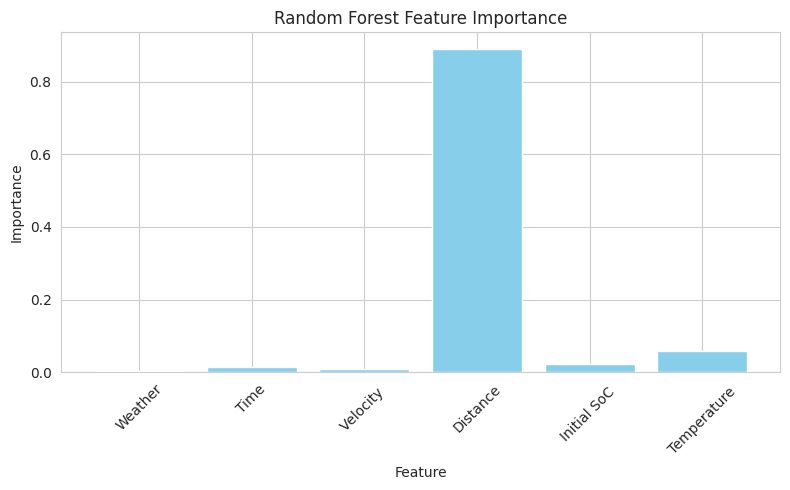

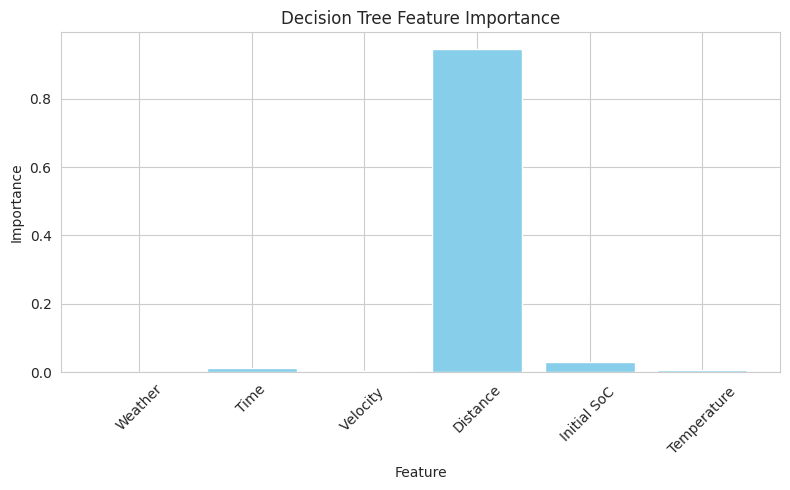

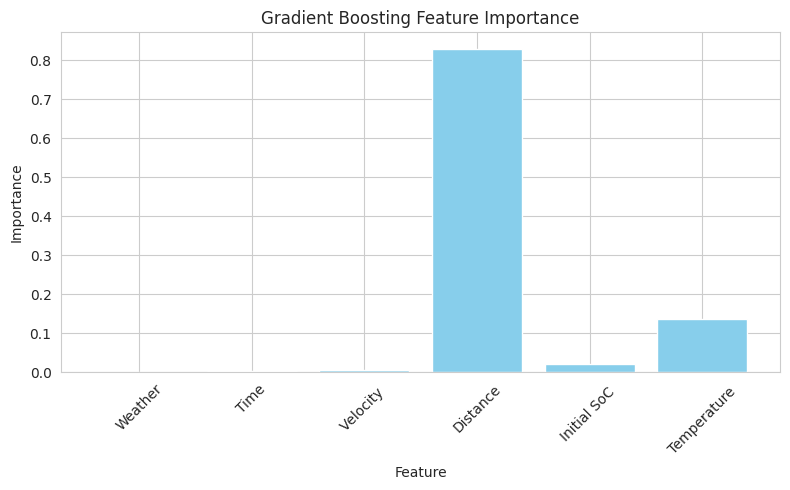

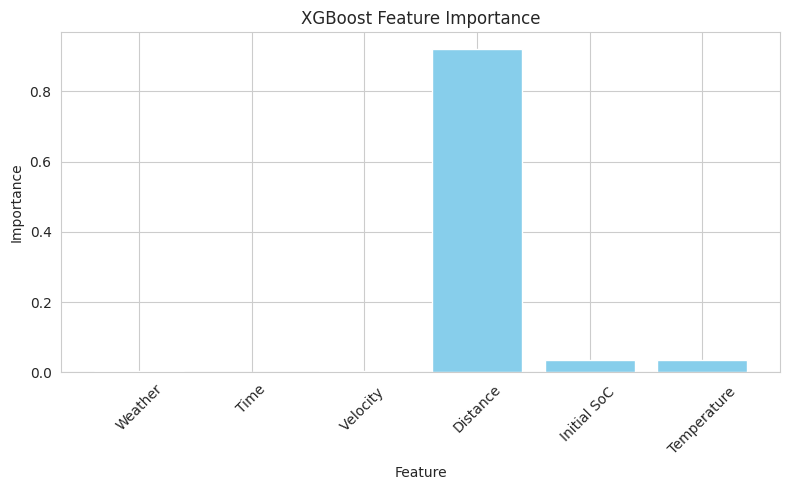

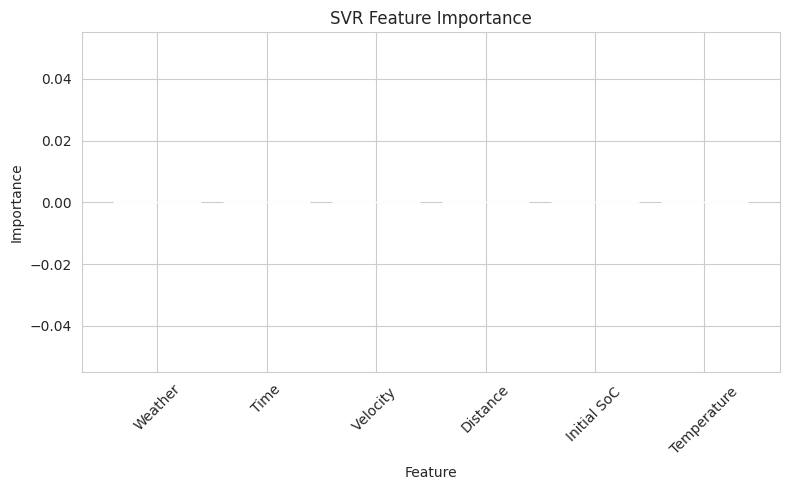

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


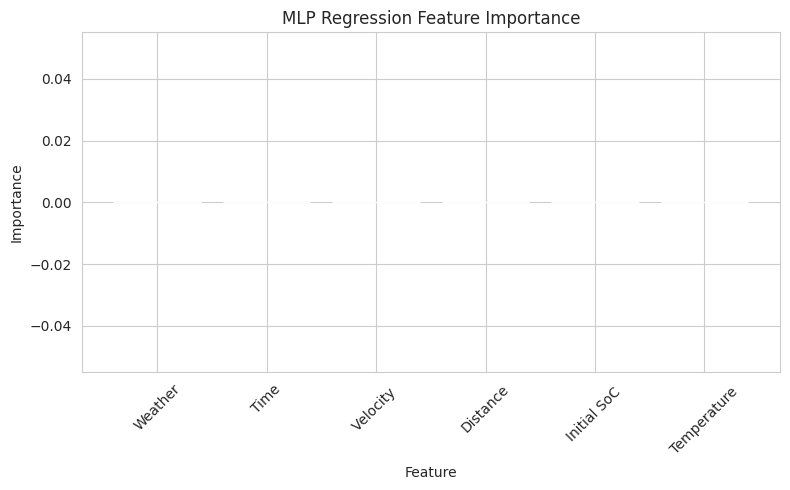

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb

df = pd.read_excel("/content/drive/MyDrive/coo.xlsx")

feature_cols = ['Weather', 'Time', 'Velocity ', 'Distance', 'Initial SoC ', ' Temperature ']
target_col = 'Used SOC'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    "SVR": SVR(),
    "MLP Regression": MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    if hasattr(model, 'coef_'):
        importance = np.abs(model.coef_)
    elif hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    else:
        importance = np.zeros(X_train.shape[1])
    plt.figure(figsize=(8, 5))
    plt.bar(feature_cols, importance, color='skyblue')
    plt.title(f'{model_name} Feature Importance')
    plt.xlabel('Feature')
    plt.ylabel('Importance')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
